In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dania\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/META.csv")

In [7]:
# Convert
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

news_df = news_df.dropna(subset=['date'])

In [23]:
#Filter ofr news 
meta_news = news_df[news_df['stock'] == 'FB'].copy()

In [24]:
#create daily filed
meta_news['date_only'] = meta_news['date'].dt.date
stock_df['date_only'] = stock_df['Date'].dt.date

In [25]:
sia = SentimentIntensityAnalyzer()

meta_news['sentiment'] = meta_news['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [26]:
meta_news['date_only'] = meta_news['date'].dt.date

meta_news['sentiment'] = pd.to_numeric(
    meta_news['sentiment'],
    errors='coerce'
)
daily_sentiment = meta_news.groupby('date_only')['sentiment'].mean().reset_index()

In [27]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['Date'].dt.date

stock_df = stock_df.sort_values('date_only')
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

In [28]:
#Aggregate daily senitment
daily_sentiment = (
    meta_news
    .groupby('date_only')['sentiment']
    .mean()
    .reset_index()
)

In [29]:
#Merge dataset
merged_df = pd.merge(
    stock_df[['date_only', 'daily_return']],
    daily_sentiment,
    on='date_only',
    how='left'
)
merged_df['sentiment'] = merged_df['sentiment'].fillna(0)
merged_df = merged_df.dropna(subset=['daily_return'])

In [30]:
# Check merged data
print("Shape:", merged_df.shape)

Shape: (2922, 3)


In [31]:
#Pearson correlation
correlation, p_value = pearsonr(
    merged_df['sentiment'],
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

Pearson Correlation: -0.008371735048285731
P-value: 0.6510148103324779


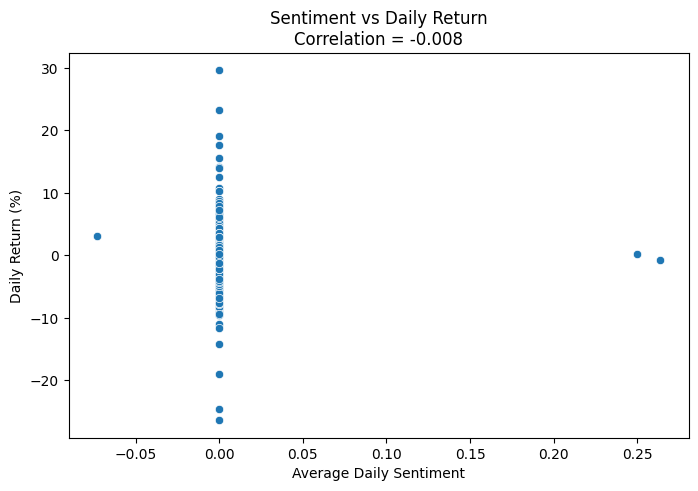

In [34]:
#scatter plot 
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=merged_df['sentiment'],
    y=merged_df['daily_return']
)

plt.title(f"Sentiment vs Daily Return\nCorrelation = {correlation:.3f}")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")

plt.show()

In [35]:
# sentimetn classification
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
merged_df['sentiment_category'] = merged_df['sentiment'].apply(classify_sentiment)

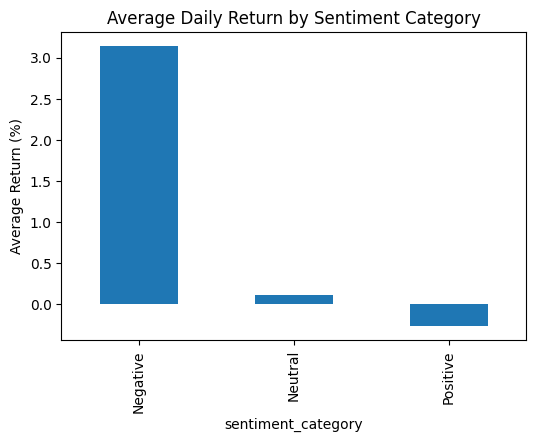

In [36]:
#barchart
avg_returns = (
    merged_df
    .groupby('sentiment_category')['daily_return']
    .mean()
)

plt.figure(figsize=(6,4))

avg_returns.plot(kind='bar')

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

Across multiple technology stocks, the correlation between news sentiment and stock returns remained weak and inconsistent. Some stocks showed slightly positive relationships, while others showed nearly zero or slightly negative correlations. These findings suggest that financial news sentiment alone is insufficient for reliably predicting short-term market performance.

In [37]:
print(merged_df.shape)
print(merged_df[['sentiment','daily_return']].corr())
print(merged_df.head())

(2922, 4)
              sentiment  daily_return
sentiment      1.000000     -0.008372
daily_return  -0.008372      1.000000
    date_only  daily_return  sentiment sentiment_category
1  2012-05-21    -10.986138        0.0            Neutral
2  2012-05-22     -8.903890        0.0            Neutral
3  2012-05-23      3.225802        0.0            Neutral
4  2012-05-24      3.218744        0.0            Neutral
5  2012-05-25     -3.390852        0.0            Neutral
